# Dynamics and control

Static stability and trim, the computed conversion corridor and its trim schedule, and trajectory
optimization through conversion and climb on the sized aircraft. The framework is point-mass; 6-DOF is planned.

In [1]:
import sys
import time
import warnings
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Stability of the baseline design

In [2]:
# The baseline design: every model at its highest fidelity (about 10 minutes from cold).
from examples.halo_sizing import (HaloAssumptions as RefAssumptions, HaloRequirements as RefRequirements,
                                  soc_emergency_floor, soc_minimum, solve_halo_sizing as solve_reference)
t0 = time.time()
ref = solve_reference()
print(f"baseline design: {ref.mass_takeoff_kg:,.0f} kg = {ref.mass_takeoff_kg / u.lbm:,.0f} lb, "
      f"empty {ref.mass_empty_kg:,.0f} kg, fuel {ref.mass_fuel_kg:,.0f} kg ({(time.time() - t0) / 60:.1f} min)")
check("baseline design closes with every margin satisfied", ref.min_margin > -1e-6)
check("baseline take-off weight 15,179 lb (+- 20)", abs(ref.mass_takeoff_kg / u.lbm - 15179) < 20)

CasADi - 2026-10-06 02:22:20 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference: 6,885 kg = 15,179 lb, empty 5,049 kg, fuel 936 kg (8.5 min)
PASS  reference closes with every margin satisfied
PASS  reference take-off weight 15,179 lb (+- 20)


In [3]:
print(f"static margin {ref.static_margin:.3f} (requirement 0.10); Cn_beta {ref.cn_beta_per_rad:.3f} /rad (requirement 0.06)")
check("static margin meets 0.10", ref.static_margin >= 0.10 - 1e-6)
check("directional stability meets 0.06 /rad", ref.cn_beta_per_rad >= 0.06 - 1e-6)

static margin 0.100 (requirement 0.10); Cn_beta 0.060 /rad (requirement 0.06)
PASS  static margin meets 0.10
PASS  directional stability meets 0.06 /rad


## 2. Conversion corridor and level-flight trim

At each nacelle angle the aircraft is trimmed in level flight (thrust, attitude, ruddervator, cyclic); the corridor
is the least and greatest airspeed with a trim inside the limits, each edge labelled with the limit that sets it.

Halo conversion corridor, 6885 kg, sea level, tip speed 238 m/s
 tilt  low kt  set by                             high kt  set by
    0   118.6  pitch_max                            218.9  rotor_power
   15   115.8  pitch_max, cyclic                    223.4  cyclic, rotor_power
   30   112.3  pitch_max, cyclic                    231.0  cyclic, placard_speed
   45   106.2  pitch_max, cyclic                    173.9  cyclic, edgewise_advance_ratio
   60    88.8  pitch_max, cyclic                    143.5  cyclic, edgewise_advance_ratio
   75    -0.0  hover                                133.5  cyclic, edgewise_advance_ratio
   90    -0.0  hover                                129.9  cyclic, edgewise_advance_ratio

Mid-corridor trim schedule
 tilt     kt  pitch   tail  cyclic   CT/s  mu_e  kW/rotor
    0  168.7    4.5   -4.7     0.0  0.012  0.03       539
   15  169.6    4.2   -4.5     2.6  0.013  0.12       520
   30  171.6    3.7   -4.2     5.0  0.015  0.21       491
   45  140.0    6.2

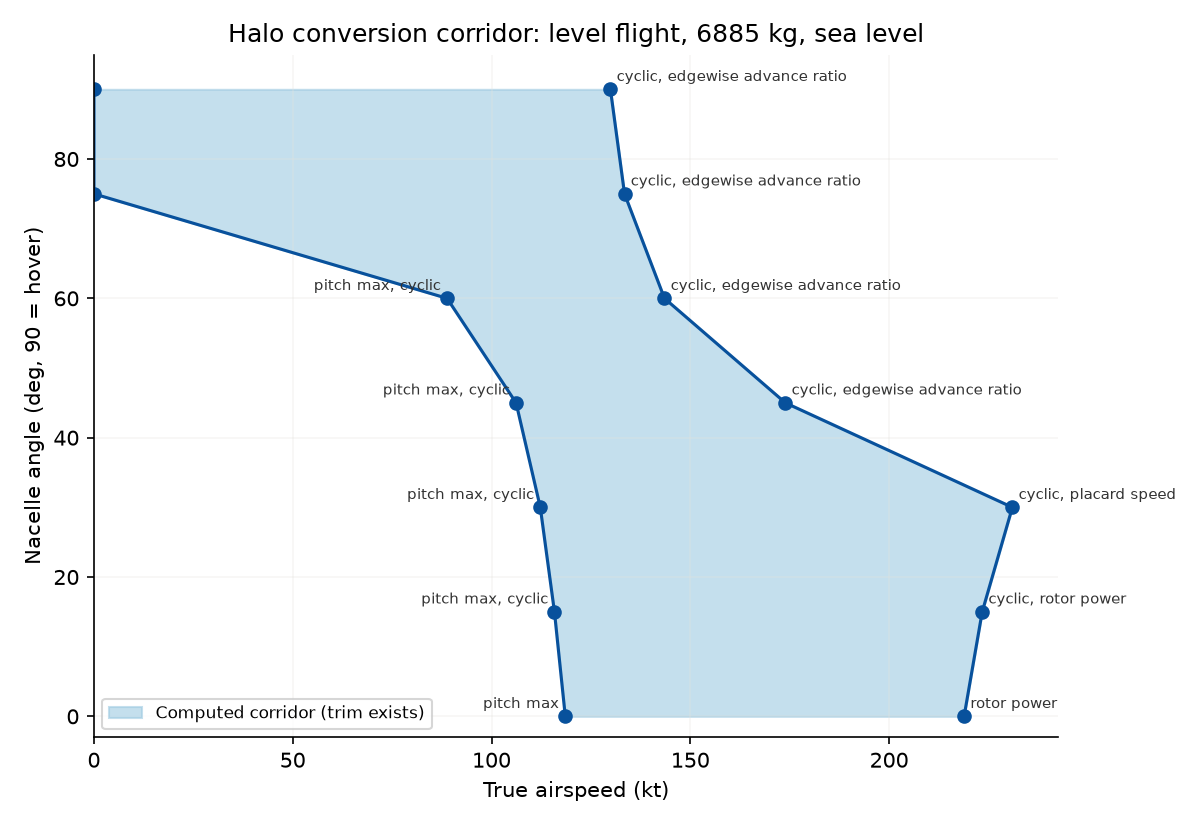

PASS  helicopter-mode high side set by edgewise flow
PASS  low side at 0-60 deg set by the attitude limit
PASS  every trim inside the +/-25 deg ruddervator


In [4]:
from IPython.display import Image, display
from examples.halo_conversion_corridor import run as run_corridor
corridor, schedule = run_corridor(ref, directory=str(repo_root / "output/corridor"))
%matplotlib inline
display(Image(filename=str(repo_root / "output/corridor/corridor.png"), width=720))
pairs = {low.tilt_deg: (low, high) for low, high in corridor}
check("helicopter-mode high side set by edgewise flow", "edgewise_advance_ratio" in pairs[90.0][1].binding)
check("low side at 0-60 deg set by the attitude limit",
      all("pitch_max" in pairs[t][0].binding for t in (0.0, 15.0, 30.0, 45.0, 60.0)))
check("every trim inside the +/-25 deg ruddervator", all(abs(t.deflection_tail_deg) <= 25 + 1e-6 for t in schedule))

## 3. Trajectories inside the computed corridor

Minimum-energy transition and minimum time to climb, flown with the computed corridor as airspeed limits.

**Finding.** The minimum-energy transition rides the corridor's low-speed side from about 15 to 100 kt and descends
slightly (inside its +/-30 m altitude band) through 15-90 kt. No level, constant-acceleration conversion exists inside
the computed corridor: with the nacelles high enough for the corridor, accelerating needs a nose-down attitude beyond
the trajectory model's -10 deg limit. The trajectory model has no cyclic to tilt the thrust, unlike the trim that
computes the corridor, so it is the stricter of the two.

Halo conversion corridor, 6885 kg, sea level, tip speed 238 m/s
 tilt  low kt  set by                             high kt  set by
    0   118.6  pitch_max                            218.9  rotor_power
   15   115.8  pitch_max, cyclic                    223.4  cyclic, rotor_power
   30   112.3  pitch_max, cyclic                    231.0  cyclic, placard_speed
   45   106.2  pitch_max, cyclic                    173.9  cyclic, edgewise_advance_ratio
   60    88.8  pitch_max, cyclic                    143.5  cyclic, edgewise_advance_ratio
   75    -0.0  hover                                133.5  cyclic, edgewise_advance_ratio
   90    -0.0  hover                                129.9  cyclic, edgewise_advance_ratio

Mid-corridor trim schedule
 tilt     kt  pitch   tail  cyclic   CT/s  mu_e  kW/rotor
    0  168.7    4.5   -4.7     0.0  0.012  0.03       539
   15  169.6    4.2   -4.5     2.6  0.013  0.12       520
   30  171.6    3.7   -4.2     5.0  0.015  0.21       491
   45  140.0    6.2

minimum-energy transition: 21.9 s, bus energy 9.59 kWh, fuel 3.1 kg, SOC 0.950 -> 0.946, peak bus power 1,635 kW
minimum time to climb: 227.5 s, bus energy 100.29 kWh, fuel 29.6 kg, SOC 0.950 -> 0.782, peak bus power 1,618 kW


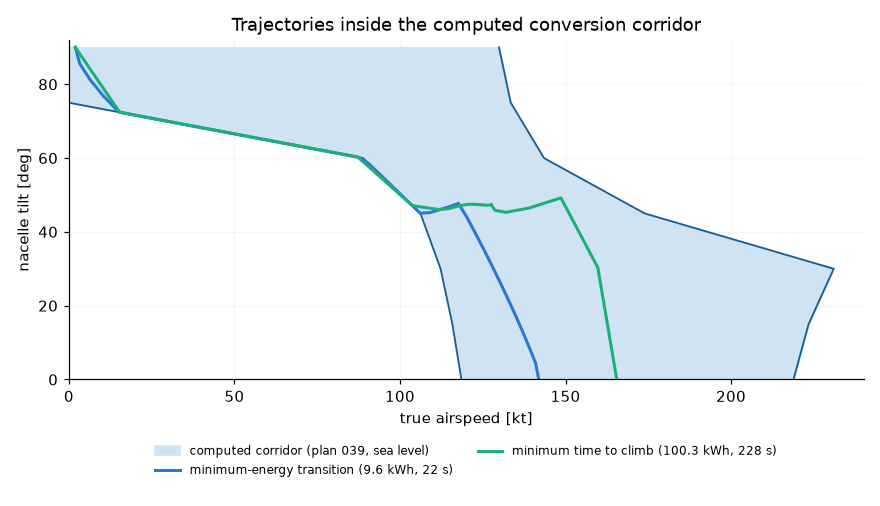

PASS  minimum-energy transition stays inside the computed corridor
PASS  minimum time to climb stays inside the computed corridor
PASS  the transition reaches wing-borne flight with the nacelles down


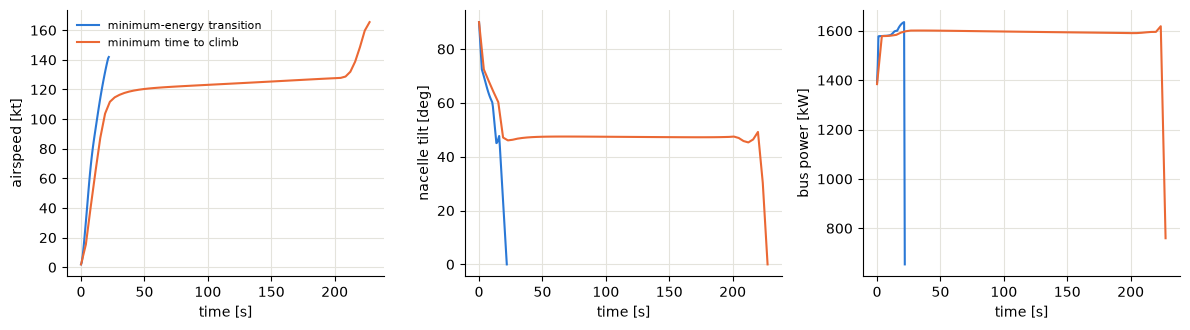

In [5]:
from examples.halo_trajectory_computed_corridor import run as run_trajectories
path = repo_root / "output/trajectory/computed_corridor.png"
case, results = run_trajectories(ref, path=str(path))
%matplotlib inline
display(Image(filename=str(path), width=720))
for result in results:
    inside = np.all(result.velocity_m_s >= result.velocity_corridor_min_m_s - 0.5) and \
        np.all(result.velocity_m_s <= result.velocity_corridor_max_m_s + 0.5)
    check(f"{result.label} stays inside the computed corridor", inside)
transition = results[0]
check("the transition reaches wing-borne flight with the nacelles down", abs(transition.tilt_deg[-1]) < 1e-3)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for result, color in zip(results, (blue, orange, aqua)):
    axes[0].plot(result.time_s, result.velocity_m_s / u.knot, color=color, label=result.label)
    axes[1].plot(result.time_s, result.tilt_deg, color=color)
    axes[2].plot(result.time_s, result.power_bus_W / 1e3, color=color)
axes[0].set(xlabel="time [s]", ylabel="airspeed [kt]")
axes[1].set(xlabel="time [s]", ylabel="nacelle tilt [deg]")
axes[2].set(xlabel="time [s]", ylabel="bus power [kW]")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Stability, trim and tail sizing building blocks

*From `tier6_stability_control/stability_control_verification.ipynb`.*

In [6]:
import ast
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.controls.stability import (DirectionalStability, LongitudinalStability, flap_effectiveness,
                                                 failed_propulsor_yaw_moment_Nm)
from examples.aircraft_mass_closure import acceleration_gravity_m_s2, build_reference_aircraft, solve_mass_closure
from examples.tail_sizing import TailSizingRequirements, solve_tail_sizing

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


closure = solve_mass_closure()
aircraft = build_reference_aircraft(closure.x_le_wing_m)
x_cg_m = closure.x_cg_m
aero, longitudinal, directional = SimpleAerodynamics(), LongitudinalStability(), DirectionalStability()
velocity_m_s, altitude_m = 60.0, 1000.0
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

### 1. Control-surface effectiveness

Thin-airfoil theory gives $\tau = 1 - (\theta_f - \sin\theta_f)/\pi$ with
$\theta_f = \arccos(2c_f/c - 1)$: zero for no flap, one for an all-moving
surface. A 0.8 factor stands in for viscous losses (stated, not calibrated).

PASS  flap: tau(0) = 0
PASS  flap: tau(1) = 1 (all-moving)
PASS  flap: monotonic in chord fraction
elevator/rudder chord fraction 0.3: tau = 0.5286 (ideal 0.6607)


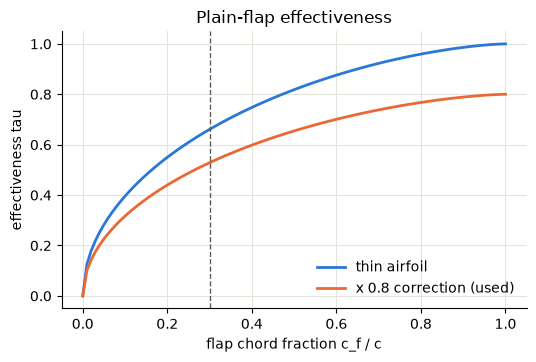

In [7]:
fractions = np.linspace(0, 1, 101)
tau_ideal = np.array([float(flap_effectiveness(f, correction=1.0)) for f in fractions])
check("flap: tau(0) = 0", abs(tau_ideal[0]) < 1e-12)
check("flap: tau(1) = 1 (all-moving)", close(tau_ideal[-1], 1.0))
check("flap: monotonic in chord fraction", np.all(np.diff(tau_ideal) > 0))
print(f"elevator/rudder chord fraction 0.3: tau = {float(flap_effectiveness(0.3)):.4f} (ideal {float(flap_effectiveness(0.3, 1.0)):.4f})")
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(fractions, tau_ideal, color=blue, lw=2, label="thin airfoil")
ax.plot(fractions, 0.8 * tau_ideal, color=orange, lw=2, label="x 0.8 correction (used)")
ax.axvline(0.3, color=ink_muted, lw=1, ls="--")
ax.set(xlabel="flap chord fraction c_f / c", ylabel="effectiveness tau", title="Plain-flap effectiveness")
ax.legend(frameon=False)
plt.show()

### 2. Neutral point and static margin

The static margin is $(x_{np} - x_{cg})/\bar c$, and by construction
$C_{m\alpha} = -SM\,C_{L\alpha,total}$; that identity is checked by finite
differences on the full pitching-moment equation. The tail moves the neutral
point aft; the fuselage moves it forward.

x_cg 3.521 m, x_np 3.662 m, static margin 12.15 % MAC
PASS  stability: Cm_alpha = -SM x CL_alpha_total (finite difference)
PASS  stability: reference aircraft is statically stable
PASS  stability: CG at the neutral point gives zero margin
PASS  stability: removing the fuselage term moves the neutral point aft
PASS  stability: static margin rises with horizontal-tail area


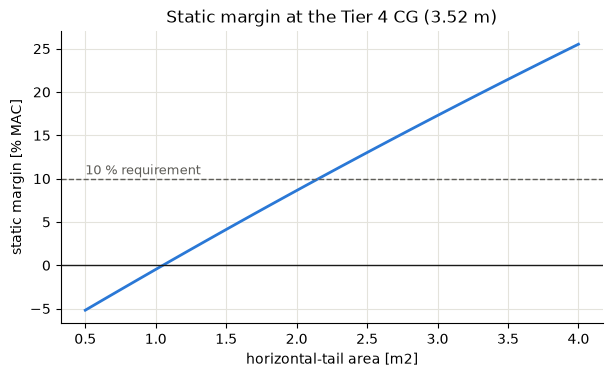

In [8]:
x_np_m = float(longitudinal.neutral_point_x_m(aircraft, aero, velocity_m_s, altitude_m))
static_margin = float(longitudinal.static_margin(aircraft, aero, x_cg_m, velocity_m_s, altitude_m))
print(f"x_cg {x_cg_m:.3f} m, x_np {x_np_m:.3f} m, static margin {100 * static_margin:.2f} % MAC")
h = 1e-4
cm_alpha = (float(longitudinal.evaluate(aircraft, aero, x_cg_m, velocity_m_s, altitude_m, 3 + h, 0).cm)
            - float(longitudinal.evaluate(aircraft, aero, x_cg_m, velocity_m_s, altitude_m, 3 - h, 0).cm)) / np.radians(2 * h)
slope_total = float(longitudinal.lift_curve_slope_total_per_rad(aircraft, aero, velocity_m_s, altitude_m))
check("stability: Cm_alpha = -SM x CL_alpha_total (finite difference)", close(cm_alpha, -static_margin * slope_total, rel=1e-6))
check("stability: reference aircraft is statically stable", static_margin > 0)
check("stability: CG at the neutral point gives zero margin", abs(float(longitudinal.static_margin(
    aircraft, aero, x_np_m, velocity_m_s, altitude_m))) < 1e-12)
check("stability: removing the fuselage term moves the neutral point aft", float(replace(
    longitudinal, fuselage_pitch_factor_per_deg=0).neutral_point_x_m(aircraft, aero, velocity_m_s, altitude_m)) > x_np_m)

areas_m2 = np.linspace(0.5, 4.0, 30)
margins = [float(longitudinal.static_margin(replace(aircraft, horizontal_tail=replace(aircraft.horizontal_tail, area_m2=a)),
                                            aero, x_cg_m, velocity_m_s, altitude_m)) for a in areas_m2]
check("stability: static margin rises with horizontal-tail area", np.all(np.diff(margins) > 0))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(areas_m2, np.array(margins) * 100, color=blue, lw=2)
ax.axhline(10, color=ink_muted, lw=1, ls="--")
ax.text(areas_m2[0], 10.5, "10 % requirement", color=ink_muted, fontsize=9)
ax.axhline(0, color=ink, lw=1)
ax.set(xlabel="horizontal-tail area [m2]", ylabel="static margin [% MAC]",
       title=f"Static margin at the Tier 4 CG ({x_cg_m:.2f} m)")
plt.show()

### 3. Pitch trim

Trim solves $C_m = 0$ and trimmed lift = weight for $\alpha$ and elevator. The
nose-down wing moment ($C_{m,ac} = -0.09$) with the CG aft of the wing
aerodynamic centre needs a download on the tail (negative tail lift, trailing
edge up). Moving the CG aft reduces the required elevator, and at the neutral
point the elevator gradient with lift coefficient vanishes (up to the small
Mach dependence of the lift slopes).

trim at 60 m/s: alpha 3.510 deg, elevator -5.146 deg, CL_tail -0.1330, trim drag CD 0.00027
PASS  trim: tail carries a download
PASS  trim: trailing-edge-up elevator
PASS  trim: tail induced drag positive and small


PASS  trim: aft CG needs less trailing-edge-up elevator
PASS  trim: elevator nearly speed-independent at the neutral point (< 2 % of reference variation)


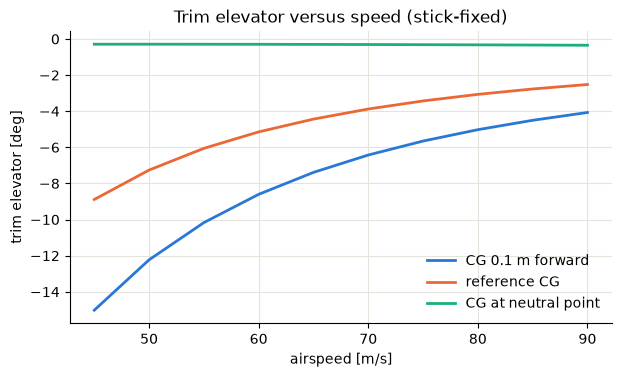

In [9]:
weight_N = closure.mass_takeoff_kg * acceleration_gravity_m_s2


def trim_at(x_cg, velocity):
    opti = asb.Opti()
    alpha = opti.variable(init_guess=3)
    elevator = opti.variable(init_guess=-3)
    result = longitudinal.evaluate(aircraft, aero, x_cg, velocity, altitude_m, alpha, elevator)
    opti.subject_to([result.cm == 0, result.lift_N == weight_N])
    sol = opti.solve(verbose=False)
    return float(sol.value(alpha)), float(sol.value(elevator)), float(sol.value(result.cl_tail)), float(sol.value(result.trim_drag.cd))


alpha_trim, elevator_trim, cl_tail_trim, trim_cd = trim_at(x_cg_m, velocity_m_s)
print(f"trim at 60 m/s: alpha {alpha_trim:.3f} deg, elevator {elevator_trim:.3f} deg, CL_tail {cl_tail_trim:.4f}, "
      f"trim drag CD {trim_cd:.5f}")
check("trim: tail carries a download", cl_tail_trim < 0)
check("trim: trailing-edge-up elevator", elevator_trim < 0)
check("trim: tail induced drag positive and small", 0 < trim_cd < 0.002)

speeds = np.linspace(45, 90, 10)
elevators_forward = [trim_at(x_cg_m - 0.1, v)[1] for v in speeds]
elevators_reference = [trim_at(x_cg_m, v)[1] for v in speeds]
elevators_neutral = [trim_at(x_np_m, v)[1] for v in speeds]
check("trim: aft CG needs less trailing-edge-up elevator", all(r > f for r, f in zip(elevators_reference, elevators_forward)))
# The neutral point was computed at 60 m/s; lift slopes carry a small Mach
# correction, so it moves slightly with speed and the elevator is nearly, not
# exactly, constant there.
check("trim: elevator nearly speed-independent at the neutral point (< 2 % of reference variation)",
      np.ptp(elevators_neutral) < 0.02 * np.ptp(elevators_reference))
fig, ax = plt.subplots(figsize=(7, 3.8))
for values, label, color in ((elevators_forward, "CG 0.1 m forward", blue), (elevators_reference, "reference CG", orange),
                             (elevators_neutral, "CG at neutral point", aqua)):
    ax.plot(speeds, values, color=color, lw=2, label=label)
ax.set(xlabel="airspeed [m/s]", ylabel="trim elevator [deg]", title="Trim elevator versus speed (stick-fixed)")
ax.legend(frameon=False)
plt.show()

### 4. Directional stability and failed-rotor yaw

$C_{n\beta}$ grows with fin area and arm; the fuselage alone is destabilizing.
With an outboard rotor failed at the wing tip, the remaining three rotors
supply level-flight drag, so the yaw moment is $(D/3)\,b/2$. The rudder needed
to hold it scales with the moment and inversely with dynamic pressure, so the
critical case is the slowest controlled speed (1.2 $V_{stall}$ here).

Cn_beta 0.0405 /rad (fuselage alone -0.0534 /rad)
PASS  directional: fuselage alone is destabilizing
PASS  directional: reference fin makes Cn_beta positive
PASS  failed rotor: required rudder is largest at the lowest speed


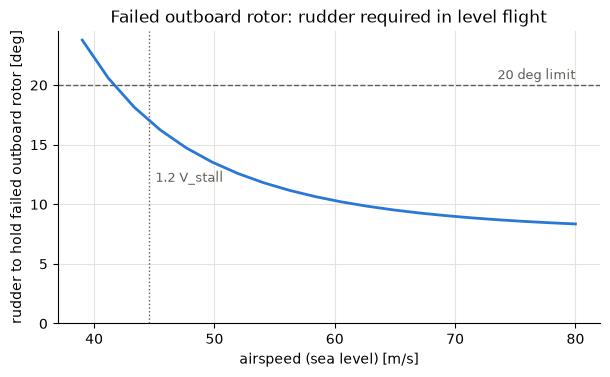

In [10]:
cn_beta = float(directional.cn_beta_per_rad(aircraft, aero, x_cg_m, velocity_m_s, altitude_m))
cn_beta_bare = float(directional.cn_beta_per_rad(replace(aircraft, vertical_tail=replace(aircraft.vertical_tail, area_m2=1e-6)),
                                                 aero, x_cg_m, velocity_m_s, altitude_m))
print(f"Cn_beta {cn_beta:.4f} /rad (fuselage alone {cn_beta_bare:.4f} /rad)")
check("directional: fuselage alone is destabilizing", cn_beta_bare < 0)
check("directional: reference fin makes Cn_beta positive", cn_beta > 0)

rho_sl = float(asb.Atmosphere(altitude=0).density())
velocity_stall = np.sqrt(2 * weight_N / (rho_sl * aircraft.wing.area_m2 * aero.cl_max))
speeds = np.linspace(1.05 * velocity_stall, 80, 20)
rudders = []
for v in speeds:
    opti = asb.Opti()
    alpha = opti.variable(init_guess=6)
    slow = aero.evaluate(aircraft, v, 0.0, alpha)
    opti.subject_to(slow.lift_N == weight_N)
    sol = opti.solve(verbose=False)
    moment = failed_propulsor_yaw_moment_Nm(float(sol.value(slow.drag_N)) / 3, aircraft.wing.span_m() / 2)
    rudders.append(float(directional.rudder_for_yaw_moment_deg(aircraft, aero, x_cg_m, v, 0.0, moment)))
check("failed rotor: required rudder is largest at the lowest speed", int(np.argmax(rudders)) == 0)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(speeds, rudders, color=blue, lw=2)
ax.axhline(20, color=ink_muted, lw=1, ls="--")
ax.text(speeds[-1], 20.5, "20 deg limit", color=ink_muted, fontsize=9, ha="right")
ax.axvline(1.2 * velocity_stall, color=ink_muted, lw=1, ls=":")
ax.text(1.2 * velocity_stall + 0.5, max(rudders) * 0.5, "1.2 V_stall", color=ink_muted, fontsize=9)
ax.set(xlabel="airspeed (sea level) [m/s]", ylabel="rudder to hold failed outboard rotor [deg]", ylim=(0, None),
       title="Failed outboard rotor: rudder required in level flight")
plt.show()

## Summary

In [11]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} of {len(check_log)} checks passed")
for name in failed:
    print("FAILED:", name)

26 of 26 checks passed
